# BEE 4310/6310: Environmental Statistics and Learning  <br> Assignment #5 Part 3 (5 pts)

**Include responses to everything below in bold (including plots), and make sure your final assignment is well organized in a single markdown PDF submitted to Canvas. This makes it easier to grade (and easier to give partial credit).**

**Remember to include an acknowledgement at the bottom of this assignment if generative AI was used for coding support, including a list of the problems for which it was used.**

**Techniques and Topics:** 
- Long Short Term Memory networks (LSTMs)

In this assignment, you will build and apply a simple LSTM to model streamflow based on several meteorological inputs (air temperature, precipitation, etc.). The problems below guide you through preprocessing the data, building an LSTM, training it, and evaluating performance on a test set. The data used in this problem is from one of the basins included in the CAMELS dataset, which is frequently used in hydrologic benchmarking studies. Specifically, the data is for basin number 9065500, which is a basin in the Rocky Mountains in Colorado.

Before beginning, import the following packages: 
- numpy
- pandas
- matplotlib.pyplot
- StandardScaler from sklearn.preprocessing
- train_test_split from sklearn.model_selection
- torch
- torch.nn as nn
- DataLoader and TensorDataset from torch.utils.data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

If you don't have torch installed yet, you can either install it via anaconda or install it with pip to the venv you have activated currently for this notebook (using the commented out code below). If you have trouble with this, I would suggest asking ChatGPT, Claude, or Gemini for guidance on the install. 

In [2]:
# %pip install torch

1. **(1 point)** The code below loads the CAMELS dataset for basin 9065500 from the CSV file `CAMELS_09065500_input.csv`. This dataset contains daily meteorological variables and observed streamflow (`qobs`) from 1980-2020.

   The meteorological variables include:
   - `precip`: precipitation (mm/day)
   - `tmax`: maximum air temperature (°C)
   - `tmin`: minimum air temperature (°C)  
   - `daylenhr`: day length (hours)
   - `srad(W/m2)`: solar radiation (W/m²)
   - `vp(Pa)`: vapor pressure (Pa)

   The observed streamflow is stored as:
   - `qobs`: streamflow (mm/day)

   The code loads the data as a pandas DataFrame, converts date to datetime format, and displays the first few rows and shape. The time series plots show observed flow and precipitation over the full record.

   **Examining the timeseries plot, does the precipitation line up closely with the streamflow, or is there a lag between precipitation and streamflow? Based on your answer, explain why an LSTM would be a useful model to try for this prediction problem.**

In [2]:
# Load CAMELS data
data = pd.read_csv('CAMELS_09065500_input.csv')

# convert to date to datetime format:
data['date'] = pd.to_datetime(data['date'], format='%m/%d/%y')
# set date as index for easier time series handling
data.set_index('date', inplace=True)

print("Data shape:", data.shape)
print("First few rows:")
print(data.head())

Data shape: (12784, 7)
First few rows:
            precip  tmax   tmin  daylenhr  srad(W/m2)  vp(Pa)    qobs
date                                                                 
1980-01-01    0.00 -2.10 -14.57     9.216      333.73  200.00  0.1489
1980-01-02   15.54 -4.54 -12.78     9.304      184.11  231.87  0.1489
1980-01-03   17.10 -7.83 -20.23     9.312      251.29  120.35  0.1489
1980-01-04   10.60 -7.76 -16.08     9.312      191.69  174.87  0.1489
1980-01-05    4.86 -3.61 -11.75     9.312      190.28  240.00  0.1748


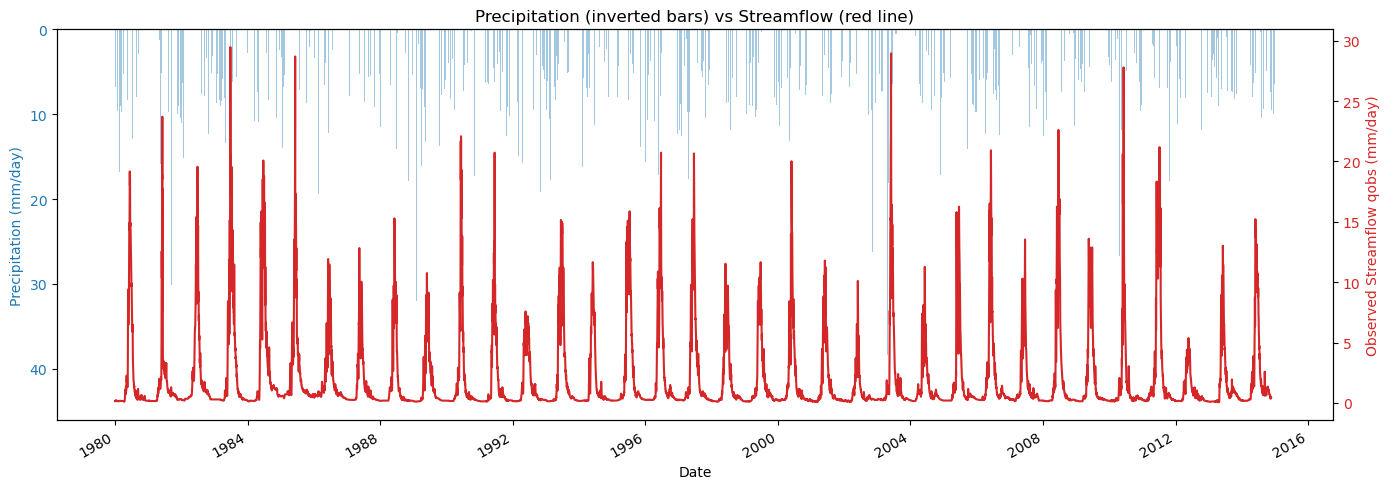

In [3]:
# Visualize both precipitation and streamflow together to show lagged response
# This illustrates how precipitation drives streamflow with a delay in snow-dominated basins
fig, ax1 = plt.subplots(figsize=(14, 5))

# Plot precipitation on left y-axis
color = 'tab:blue'
ax1.set_xlabel('Date')
ax1.set_ylabel('Precipitation (mm/day)', color=color)
ax1.bar(data.index, data['precip'], color=color, alpha=0.4, label='Precip')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim([data['precip'].max() * 1.2, 0])  # Invert y-axis so precip shows downward

# Plot streamflow on right y-axis
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Observed Streamflow qobs (mm/day)', color=color)
ax2.plot(data.index, data['qobs'], color=color, linewidth=1.5, label='qobs')
ax2.tick_params(axis='y', labelcolor=color)
fig.autofmt_xdate()
plt.title('Precipitation (inverted bars) vs Streamflow (red line)')
fig.tight_layout()
plt.show()

#### The reason that LSTM works well for prediction
Yes, the figure **shows a lag** between precipitation and streamflow.

An LSTM (Long Short-Term Memory network) is well-suited for this problem for these reasons:
1. LSTM's hidden state and cell state allow model to simultaneously remember short-term and long-term information, which can handle lagged relationship more naturally. For example, the LSTM model can simultaneously track both rapid storm-driven runoff responses and slow multi-week groundwater drainage processes.
2. LSTM can selective memory via gating. The forget, input, and output gates allow the LSTM to learn which past information to retain and when to discard it. For example, soil moisture conditions from weeks prior can be kept in the cell state and used to modulate how today's precipitation translates into runoff.

2. **(1 point)** In this problem, you will preprocess the data for LSTM training, following proper data preprocessing practices to prevent data leakage. Note that steps (a), (b), and (c) have been done for you, but steps (d) and (e) still need to be coded up:

   a) Remove rows with missing values.

   b) **Split the data into training (70%) and testing (30%) sets**, using train_test_split with shuffle set to false to preserve the temporal order (required for time series data). After splitting, save the size of the training set as `train_size = len(train_data)` — you will need this value later to correctly index dates when evaluating the model.

   c) **Standardize only the feature columns** (not the target `qobs`), fitting the scaler on training data only. First, define the following two variables that will be used throughout the rest of the assignment:
      - `features = ['precip', 'tmax', 'tmin', 'daylenhr', 'srad(W/m2)', 'vp(Pa)']`
      - `target = 'qobs'`

      Then create copies of `train_data` and `test_data` called `train_scaled` and `test_scaled`. Use `scaler.fit_transform(train_data[features])` to fit and apply the StandardScaler to only the feature columns of the training copy, and `scaler.transform(test_data[features])` to apply the same fitted scaler to the test copy. Leave `qobs` untouched in both copies so that model predictions will be directly interpretable in mm/day.

   d) **Create the `create_sequences()` function**: This function will convert your time series data into sequences suitable for LSTM training. The function should take the following inputs:
      - `data`: a DataFrame containing the preprocessed time series data
      - `features`: the list of feature column names
      - `target`: the string column name of the variable to predict
      - `lookback`: an integer specifying the number of time steps to use as input (e.g., 30 days)
      
      The function should iterate through the data, creating overlapping sequences where each input sequence contains `lookback` time steps of the features, and the corresponding output is the target value on the last time step of the sequence. Return two numpy arrays: `X` (shape: [num_sequences, lookback, num_features]) and `y` (shape: [num_sequences]).

   e) **Generate sequences from scaled training and test data separately**: Using the `create_sequences()` function you created in part (d), generate sequences from `train_scaled` to produce `X_train` and `y_train`, and generate sequences from `test_scaled` to produce `X_test` and `y_test`. This maintains temporal continuity within each set and prevents data leakage. Define a `lookback_window` variable equal to 30 days for this experiment.  
   
   **Print the shapes of all four arrays (`X_train`,`y_train`,`X_test`,`y_test`) to verify they are correct. These shapes will be how we evaulate your work on this question, so don't forget this step!**

In [4]:
# Remove rows with NaN values
data = data.dropna()
print("Data shape after dropping NaN:", data.shape)

# Split data into train/test BEFORE scaling to prevent data leakage
# shuffle=False preserves temporal order (required for time series data)
train_data, test_data = train_test_split(data, test_size=0.3, shuffle=False)
train_size = len(train_data)

print("Train data shape:", train_data.shape)
print("Test data shape:", test_data.shape)

# Define feature and target column names
features = ['precip', 'tmax', 'tmin', 'daylenhr', 'srad(W/m2)', 'vp(Pa)']
target = 'qobs'

# Standardize ONLY the feature columns (qobs left in original mm/day units)
# Fit on training data only to prevent data leakage
scaler = StandardScaler()
train_scaled = train_data.copy()
train_scaled[features] = scaler.fit_transform(train_data[features])

# Apply the SAME fitted scaler to test feature columns (transform only, don't fit)
test_scaled = test_data.copy()
test_scaled[features] = scaler.transform(test_data[features])

Data shape after dropping NaN: (12741, 7)
Train data shape: (8918, 7)
Test data shape: (3823, 7)


In [5]:
## --- Create sequences with lookback window --- ##

def create_sequences(data, features, target, lookback=30):
    X_list, y_list = [], []
    feature_vals = data[features].values   # (N, num_features)
    target_vals  = data[target].values     # (N,)
    for i in range(lookback, len(data)):
        X_list.append(feature_vals[i - lookback : i, :])  # (lookback, num_features)
        y_list.append(target_vals[i - 1])                 # scalar — last step target
    X = np.array(X_list)   # (num_sequences, lookback, num_features)
    y = np.array(y_list)   # (num_sequences,)
    return X, y


# Define lookback_window 
lookback_window = 30

# Create sequences directly on the scaled training data, and print the shape of X_train and y_train
X_train, y_train = create_sequences(train_scaled, features, target, lookback_window)
print(f"X_train : {X_train.shape}")   # (n_train_seq, 30, 6)
print(f"y_train : {y_train.shape}")   # (n_train_seq,)

# Create sequences directly on the scaled test data, and print the shape of X_test and y_test
X_test,  y_test  = create_sequences(test_scaled,  features, target, lookback_window)
print(f"X_test  : {X_test.shape}")    # (n_test_seq,  30, 6)
print(f"y_test  : {y_test.shape}")    # (n_test_seq,)


X_train : (8888, 30, 6)
y_train : (8888,)
X_test  : (3793, 30, 6)
y_test  : (3793,)


3. **(1 point)** In this problem, you will implement an LSTM model in PyTorch. Parts (a), (b), (c), and (d) have been provided to you, but parts (e), (f), and (g) still need to be completed.  

   Create a PyTorch LSTM model class with the following specifications:
   
   a) Define a class called `LSTMModel` that inherits from `nn.Module`.
   
   b) Define the `__init__` method, which accept parameters: `input_size`, `hidden_size`, `num_layers`, and `output_size`. Store `hidden_size` and `num_layers` as instance variables.
   
   c) In `__init__`, create an LSTM layer using `nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)` and store it as `self.lstm`. 
   
   d) In `__init__`, create a dropout layer using `nn.Dropout(0.2)` and a linear output layer using `nn.Linear(hidden_size, output_size)` and store them as `self.dropout` and `self.linear`, respectively. Note that in LSTMs, we generally dropout to the linear layer, not the LSTM layer.
   
   e) Define the `forward` method that:
      - Initializes hidden state `h0` as a zeros tensor with shape `(num_layers, batch_size, hidden_size)`.  
      - Initializes cell state `c0` as a zeros tensor with the same shape as `h0`
      - Passes `x` and `(h0, c0)` through the LSTM layer: `out, _ = self.lstm(x, (h0, c0))`
      - Takes the output from the last time step: `out[:, -1, :]`
      - Passes this through the dropout layer, then the linear layer, and returns the result
   
   f) After the class definition, set the model parameters:
      - `input_size = len(features)` (should be 6)
      - `hidden_size = 128`
      - `num_layers = 1` (sufficient for streamflow prediction with meteorological inputs)
      - `output_size = 1` (for regression)
   
   g) **Instantiate the model with these parameters and print the model architecture. Your work on this problem will be evaluated based on the output of the printed model architecture.**

In [6]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # LSTM layer (dropout in LSTM only applies when num_layers > 1)
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)

        # Dropout and output layer for single-layer models
        self.dropout = nn.Dropout(0.2)
        self.linear = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        batch_size = x.size(0)
        # Initialize hidden and cell states
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size)
        c0 = torch.zeros_like(h0)
        # Forward pass through LSTM
        out, _ = self.lstm(x, (h0, c0))
        # Take the output from the last time step, apply dropout, then linear
        out = out[:, -1, :]         # (batch_size, hidden_size)
        out = self.dropout(out)
        out = self.linear(out)      
        return out


# Set the model parameters
input_size  = len(features)   # 6 meteorological features
hidden_size = 128
num_layers  = 1
output_size = 1 

# Create and print out the model
model = LSTMModel(input_size, hidden_size, num_layers, output_size)
print(model)


LSTMModel(
  (lstm): LSTM(6, 128, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (linear): Linear(in_features=128, out_features=1, bias=True)
)


4. **(1 point)** In this problem you will train the LSTM model.

   Implement the following training pipeline for your LSTM model:

   a) **Convert data to PyTorch tensors**: Convert the numpy arrays `X_train`, `y_train`, `X_test`, and `y_test` to PyTorch tensors. Use `torch.FloatTensor()` for the input sequences `X_train` and `X_test`. For the target arrays `y_train` and `y_test`, use `torch.FloatTensor()` and add an extra dimension using `.unsqueeze(1)` to make them shape `[num_samples, 1]`.

   b) **Create DataLoader for batching**: Set `batch_size = 32`. Create a `TensorDataset` from `X_train_tensor` and `y_train_tensor`, then create a `DataLoader` with this dataset, the batch size, and `shuffle=True` to randomize the order of training samples.

   c) **Set up loss function and optimizer**: Create an MSE loss function using `nn.MSELoss()`. Create an Adam optimizer using `torch.optim.Adam()` with the model parameters and a learning rate of `0.001`.

   d) **Initialize training parameters**: Set `num_epochs = 30` and create an empty list called `train_losses` to track the loss history.

   e) **Implement the training loop**: 
      - Loop over `num_epochs` (*HINT: while developing the training loop, set num_epochs to something smaller e.g., 5, to make sure the loop executes correctly, then change it back to 30.*)
      - Set the model to training mode with `model.train()`
      - Initialize `epoch_loss = 0.0` for accumulating loss within the epoch
      - Loop over batches from the `train_loader`:
        - Perform forward pass: `outputs = model(X_batch)`
        - Calculate loss: `loss = criterion(outputs, y_batch)`
        - Zero gradients: `optimizer.zero_grad()`
        - Backward pass: `loss.backward()`
        - Update weights: `optimizer.step()`
        - Accumulate loss: `epoch_loss += loss.item()`
      - Calculate average epoch loss: `avg_epoch_loss = epoch_loss / len(train_loader)`
      - Append to `train_losses`

   f) **Visualize training progress**: **After training completes, create a plot showing the training loss over epochs using matplotlib. Include appropriate labels and title.**

Epoch [  1/30]  |  Avg MSE Loss: 5.2826
Epoch [  5/30]  |  Avg MSE Loss: 2.0808
Epoch [ 10/30]  |  Avg MSE Loss: 1.6272
Epoch [ 15/30]  |  Avg MSE Loss: 1.2736
Epoch [ 20/30]  |  Avg MSE Loss: 0.8581
Epoch [ 25/30]  |  Avg MSE Loss: 0.5888
Epoch [ 30/30]  |  Avg MSE Loss: 0.5417

Training complete.
Initial loss : 5.2826
Final   loss : 0.5417


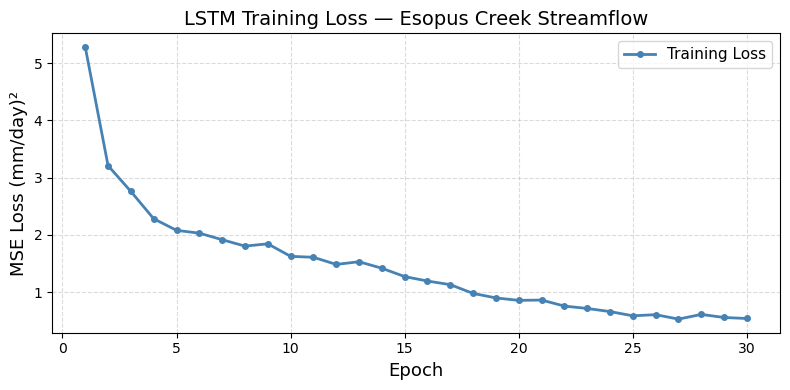

In [7]:
# Convert data to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train)            
X_test_tensor  = torch.FloatTensor(X_test)           
y_train_tensor = torch.FloatTensor(y_train).unsqueeze(1) 
y_test_tensor  = torch.FloatTensor(y_test).unsqueeze(1) 


# Create DataLoaders
batch_size   = 32
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader  = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)


# Loss function and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


# Training parameters
num_epochs   = 30
train_losses = []

# Plot training loss
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    for X_batch, y_batch in train_loader:
        # Forward pass
        outputs = model(X_batch)
        # Compute loss
        loss = criterion(outputs, y_batch)
        # Zero gradients, backward pass, update weights
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        # Accumulate batch loss
        epoch_loss += loss.item()
    # Average loss over all batches in this epoch
    avg_epoch_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_epoch_loss)
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1:>3}/{num_epochs}]  |  "
              f"Avg MSE Loss: {avg_epoch_loss:.4f}")
print(f"\nTraining complete.")
print(f"Initial loss : {train_losses[0]:.4f}")
print(f"Final   loss : {train_losses[-1]:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, num_epochs + 1), train_losses,
        color='steelblue', linewidth=2.0, marker='o',
        markersize=4, label='Training Loss')
ax.set_xlabel('Epoch',    fontsize=13)
ax.set_ylabel('MSE Loss (mm/day)²', fontsize=13)
ax.set_title('LSTM Training Loss — Esopus Creek Streamflow', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.45)
plt.tight_layout()
plt.savefig('lstm_training_loss.png', dpi=150)
plt.show()


5. **(1 point)** In this problem, you will evaluate the trained model on the test set.

   Generate predictions on the test data, calculate performance metrics, and create visualizations by completing the following steps:

   a) **Generate predictions**: Set the model to evaluation mode with `model.eval()`. Inside a `torch.no_grad()` block, generate predictions on the test set by passing `X_test_tensor` through the model and calling `.numpy().flatten()`. This gives you predictions as a 1D numpy array in mm/day.

   b) **Calculate performance metrics**: Import the necessary functions from sklearn (`mean_squared_error`, `mean_absolute_error`, `r2_score`). Calculate:
      - RMSE: `np.sqrt(mean_squared_error(y_test, test_predictions))`
      - MAE: `mean_absolute_error(y_test, test_predictions)`
      - R²: `r2_score(y_test, test_predictions)`
      
      Print these metrics with descriptive labels. Because `qobs` was left in its original units, RMSE and MAE are directly interpretable in mm/day.

   c) **Create date index for test predictions**: The test predictions correspond to dates starting from `train_size + lookback_window` in the original data index. Create `test_dates = data.index[train_size + lookback_window:train_size + lookback_window + len(test_predictions)]` to get the correct dates for plotting.

   d) **Create scatter plot**: Plot predicted vs observed streamflow values using matplotlib. Include a 1:1 reference line, proper axis labels (mm/day), title, and grid.

   e) **Create time series plot**: Plot both observed and predicted streamflow over time for the test period. Use `test_dates` for the x-axis. Include a legend, axis labels (mm/day), and title.


  **In this assignment, we kept the lookback window relatively small (30 days) for computational efficiency, but LSTMs used for streamflow prediction often have a lookback window of 270 or 365 days. Why do you think that is? If you repeated all the steps above with a small lookback window (e.g., 5 days), do you think the model performance would be worse? Why or why not?**

  RMSE : 1.7414 mm/day
  MAE  : 0.7347  mm/day
  R²   : 0.7557


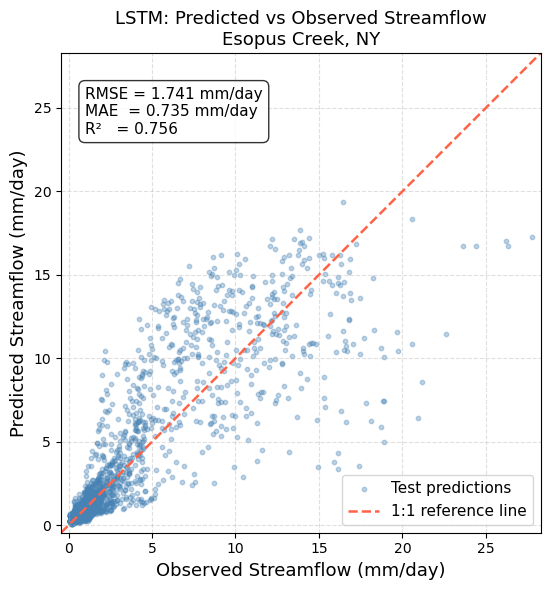

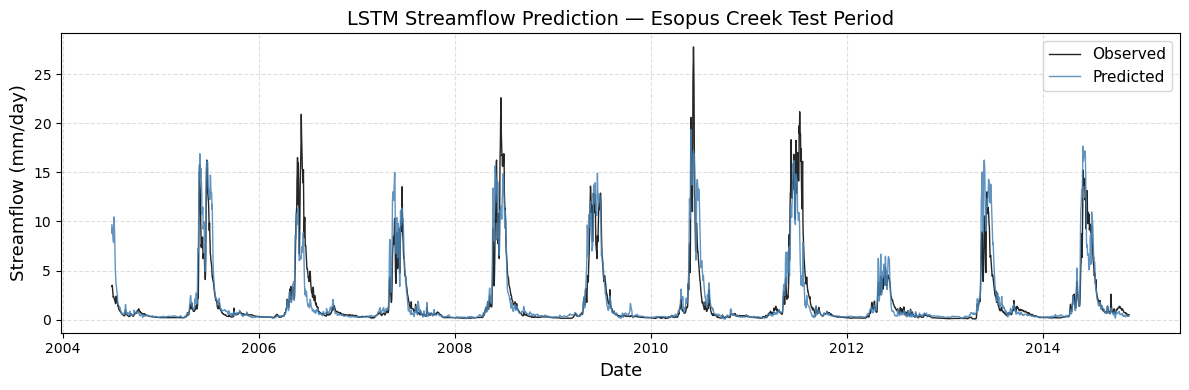

In [12]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Generate predictions on test set (mm/day)
model.eval()
with torch.no_grad():
    test_predictions = model(X_test_tensor).numpy().flatten()  # 1D array, mm/day
y_test_np = y_test_tensor.numpy().flatten()   # observed, mm/day

# Calculate and print performance metrics (mm/day)
rmse = np.sqrt(mean_squared_error(y_test_np, test_predictions))
mae  = mean_absolute_error(y_test_np, test_predictions)
r2   = r2_score(y_test_np, test_predictions)
print(f"  RMSE : {rmse:.4f} mm/day")
print(f"  MAE  : {mae:.4f}  mm/day")
print(f"  R²   : {r2:.4f}")

# Create date index for test predictions
test_dates = data.index[
    train_size + lookback_window :
    train_size + lookback_window + len(test_predictions)]

# Scatter plot: predicted vs observed
line_min = min(y_test_np.min(), test_predictions.min()) - 0.5
line_max = max(y_test_np.max(), test_predictions.max()) + 0.5
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test_np, test_predictions,
           color='steelblue', alpha=0.35, s=10, label='Test predictions')
ax.plot([line_min, line_max], [line_min, line_max],
        color='tomato', linewidth=1.8, linestyle='--', label='1:1 reference line')
ax.set_xlim(line_min, line_max)
ax.set_ylim(line_min, line_max)
ax.set_xlabel('Observed Streamflow (mm/day)',  fontsize=13)
ax.set_ylabel('Predicted Streamflow (mm/day)', fontsize=13)
ax.set_title('LSTM: Predicted vs Observed Streamflow\nEsopus Creek, NY', fontsize=13)
ax.text(0.05, 0.93,
        f'RMSE = {rmse:.3f} mm/day\nMAE  = {mae:.3f} mm/day\nR²   = {r2:.3f}',
        transform=ax.transAxes, fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.8))
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4)
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('lstm_scatter.png', dpi=150)
plt.show()

# Time series plot
test_dates_dt = data.index[
    train_size + lookback_window :
    train_size + lookback_window + len(test_predictions)
].values
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(test_dates_dt, y_test_np,
        color='black',     linewidth=1.0, label='Observed',  alpha=0.85)
ax.plot(test_dates_dt, test_predictions,
        color='steelblue', linewidth=1.0, label='Predicted', alpha=0.85)
ax.set_xlabel('Date',                   fontsize=13)
ax.set_ylabel('Streamflow (mm/day)',    fontsize=13)
ax.set_title('LSTM Streamflow Prediction — Esopus Creek Test Period', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('lstm_timeseries.png', dpi=150)
plt.show()


#### Model performance with a small lookback window
- For 270 / 365 day lookback: In this case, hydrological memory is long. LSTM model can catch both recent rainfall and slow processes like groundwater recharge or soil moisture conditions. Therefore, A 270 / 365 day window gives the LSTM model enough context to learn both short-term signal and seasonal signal.

- **For 5 day loockback: I think the model performance will be worse**. With only 5 days of context the model would be limited to capturing rapid runoff from recent rainfall. Therefore, it would struggle to predict baseflow, seasonal peaks or drought recession curves.